# Logistic Regression - Supervised Binary Classification Task

Logistic Regression (LR) is a linear classifier that models the probability of a class (e.g., donor vs. non-donor) using a sigmoid function, and predicts based on that probability. It learns coefficients for each feature by optimizing a loss function (with optional regularization). This pipeline includes data preprocessing, specific for this model, followed by the training and the evaluation of the classifier. 
 
Data preprocessing:





**Several hyperparameters can be tested using this pipeline:**

C: Controls regularization strength, with a trade-off between fitting the training data vs keeping weights small. Higher C means less regularization and higher coefficients, and a lower C leads to more regularization and weights closer to zero. 

penalty: The type of regularization. Each has their own advantages and drawbacks. l2 penalizes large coefficients while l1 will zero smaller coefficients, as examples. 

solver: the optimization algorithm used to fit the logistic regression parameters.

max_iter: the maximum number of iterations the solver is allowed to run. If it’s too low, the solver might stop early (not converge) and you may need to increase it.


Results and Discussion:

- Balancing standardization of the data had a big impact in the results, especially in the donor class, that we are particularly interested in detecting. So we kept both. This can be easly observed by changing the STANDARDIZE and BALANCE variables in the code below. 

- We first experimented with different sets of features, namely the groups of features A and B, that we had previously selected. The increase in the number of features seemed to improve the results, so we also tried with larger sets of both categorical and numerical features. The best results were obtained with the full set of all complete numerical features, so we kept those, as can be seen in the example below. Using incomplete and/or categorical features led to worst or similar results. Further exploration was performed by looking at the specific coeficient of each feature and keeping only the highest coeficients, but it led to no improvement. 

- The code below presents the implementation with the best results. 

- The experiments with the C value, penalty and solver can be seen in the next section.
 

TARGET_B                           0
MONTHS_SINCE_ORIGIN                0
IN_HOUSE                           0
MOR_HIT_RATE                       0
MEDIAN_HOME_VALUE                  0
                                  ..
NUMBER_PROM_12_unknown             0
MONTHS_SINCE_LAST_GIFT_unknown     0
MONTHS_SINCE_FIRST_GIFT_unknown    0
FILE_AVG_GIFT_unknown              0
FILE_CARD_GIFT_unknown             0
Length: 71, dtype: int64
Train set score (Accuracy) = 0.6012113703627229
Test set score (Accuracy)  = 0.5907495354119348



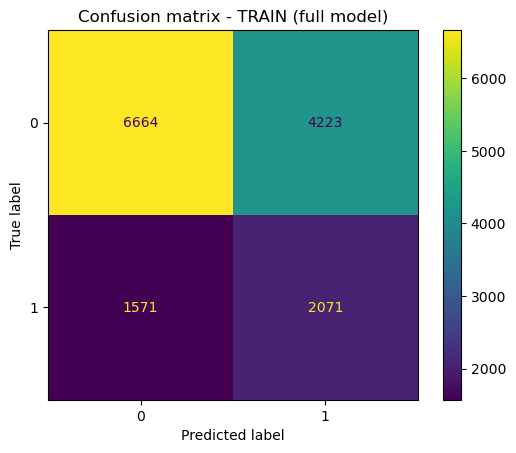

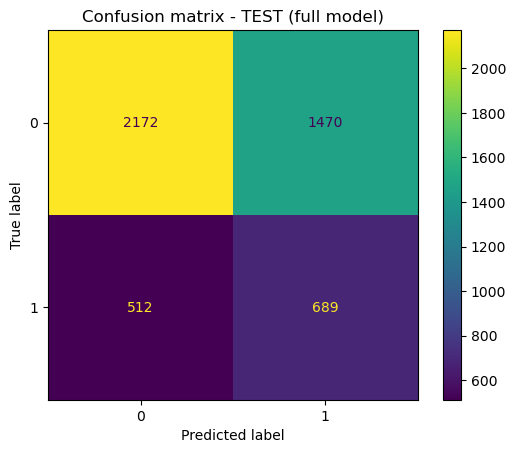


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.81      0.61      0.70     10887
           1       0.33      0.57      0.42      3642

    accuracy                           0.60     14529
   macro avg       0.57      0.59      0.56     14529
weighted avg       0.69      0.60      0.63     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      3642
           1       0.32      0.57      0.41      1201

    accuracy                           0.59      4843
   macro avg       0.56      0.59      0.55      4843
weighted avg       0.69      0.59      0.62      4843



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df_donors = pd.read_csv('Donors_dataset.csv')

STANDARDIZE = False
BALANCE = True
#label_balance = 'balanced'
# you can make your balance between the two labels by adding a new label_weight as a dictionary:
# label_weight = {0: 1.0, 1: 2.0}

# Default parameters can be consulted here: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
C = 1
penalty = 'l2' # or l1
solver = 'liblinear'
max_iter = 100

# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.


num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]

cat_features = [
]


# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# Treating the missing values. 
for col in num_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    median_val = df_B[col].median()
    df_B[col] = df_B[col].fillna(median_val)

for col in cat_features:
    df_B[col] = df_B[col].fillna("Unknown")

# check missing values
print(df_B.isna().sum())

# One-hot encode only the categorical features
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True)

X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

if STANDARDIZE:
    sc = StandardScaler()
    sc.fit(X_B_train)
    X_train_used = sc.transform(X_B_train)
    X_test_used  = sc.transform(X_B_test)
else:
    X_train_used = X_B_train
    X_test_used  = X_B_test

if BALANCE:
    class_weight = 'balanced'
else:
    class_weight = None

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver,
                                 max_iter=max_iter, class_weight=class_weight)
logreg_full.fit(X_train_used, y_B_train)

# Accuracy
print("Train set score (Accuracy) =", logreg_full.score(X_train_used, y_B_train))
print("Test set score (Accuracy)  =", logreg_full.score(X_test_used, y_B_test))

print()


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_train_used)
y_B_test_pred  = logreg_full.predict(X_test_used)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))
